# Análise Exploratória - CHAMADOS

Este notebook realiza uma análise exploratória dos dados do arquivo `chamados-clean.csv`.

Objetivos:
- Inspecionar estrutura dos dados
- Avaliar qualidade dos dados
- Gerar estatísticas descritivas
- Analisar correlações


In [4]:
# Imports necessários
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DIRETORIO_ATUAL = Path.cwd()
CAMINHO_DATASET = DIRETORIO_ATUAL.parent / "data" / "clean" / "chamados-clean.csv"

In [5]:
df = pd.read_csv(CAMINHO_DATASET)
df.head()

,ticket_id,created_at,customer_id,department,city_x,state_x,device_type,os,browser,network_type,...,vip,monthly_revenue,num_events,last_event_date,event_types,num_abertura,num_updates,num_encerramento,num_images_y,target_category
0,1,2025-01-01T00:17:00,5012,Operações,Campinas,BA,Desktop,Windows,Safari,WiFi,...,NaN,NaN,0,NaN,NaN,0,0,0,NaN,Hardware
1,2,2025-01-01T00:34:00,6574,Financeiro,Campinas,RJ,Notebook,Windows,Chrome,5G,...,NaN,NaN,0,NaN,NaN,0,0,0,NaN,RH
2,3,2025-01-01T00:51:00,2139,TI,Campinas,MG,Desktop,Linux,Chrome,5G,...,NaN,NaN,0,NaN,NaN,0,0,0,NaN,Financeiro
3,4,2025-01-01T01:08:00,7216,Financeiro,Belo Horizonte,RJ,Mobile,Android,Chrome,Cabo,...,NaN,NaN,0,NaN,NaN,0,0,0,NaN,Software
4,5,2025-01-01T01:25:00,5040,Financeiro,Belo Horizonte,PR,Mobile,iOS,Edge,Cabo,...,NaN,NaN,0,NaN,NaN,0,0,0,NaN,Rede


In [6]:
linhas, colunas = df.shape

print("Linhas:", linhas)
print("Colunas:", colunas)

Linhas: 5000
Colunas: 44


In [7]:
df.columns

Index(['ticket_id', 'created_at', 'customer_id', 'department', 'city_x',
       'state_x', 'device_type', 'os', 'browser', 'network_type',
       'historical_tickets', 'sla_hours', 'resolution_time_hours', 'title',
       'description', 'image_path', 'image_width', 'image_height', 'priority',
       'status', 'assigned_team', 'has_attachment', 'sentiment_score',
       'num_words', 'num_images_x', 'latitude', 'longitude', 'company',
       'segment', 'employees', 'city_y', 'state_y', 'contract_type',
       'customer_since', 'vip', 'monthly_revenue', 'num_events',
       'last_event_date', 'event_types', 'num_abertura', 'num_updates',
       'num_encerramento', 'num_images_y', 'target_category'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_id              5000 non-null   int64  
 1   created_at             5000 non-null   str    
 2   customer_id            5000 non-null   int64  
 3   department             5000 non-null   str    
 4   city_x                 5000 non-null   str    
 5   state_x                5000 non-null   str    
 6   device_type            5000 non-null   str    
 7   os                     5000 non-null   str    
 8   browser                5000 non-null   str    
 9   network_type           5000 non-null   str    
 10  historical_tickets     5000 non-null   int64  
 11  sla_hours              5000 non-null   int64  
 12  resolution_time_hours  5000 non-null   int64  
 13  title                  5000 non-null   str    
 14  description            5000 non-null   str    
 15  image_path     

In [16]:
df["created_at"] = pd.to_datetime(df["created_at"])

In [17]:
df.isnull().sum()

ticket_id                   0
created_at                  0
customer_id                 0
department                  0
city_x                      0
state_x                     0
device_type                 0
os                          0
browser                     0
network_type                0
historical_tickets          0
sla_hours                   0
resolution_time_hours       0
title                       0
description                 0
image_path                  0
image_width                 0
image_height                0
priority                    0
status                      0
assigned_team               0
has_attachment              0
sentiment_score             0
num_words                   0
num_images_x                0
latitude                    0
longitude                   0
company                  4998
segment                  4998
employees                4998
city_y                   4998
state_y                  4998
contract_type            4998
customer_s

In [18]:
df[df.duplicated()]

,ticket_id,created_at,customer_id,department,city_x,state_x,device_type,os,browser,network_type,...,vip,monthly_revenue,num_events,last_event_date,event_types,num_abertura,num_updates,num_encerramento,num_images_y,target_category


In [19]:
df.describe()

,ticket_id,created_at,customer_id,historical_tickets,sla_hours,resolution_time_hours,image_width,image_height,has_attachment,sentiment_score,...,longitude,employees,monthly_revenue,num_events,last_event_date,event_types,num_abertura,num_updates,num_encerramento,num_images_y
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000,5000.00000,...,5000.000000,2.000000,2.000000,5000.0,0.0,0.0,5000.0,5000.0,5000.0,0.0
mean,2500.500000,2025-01-30 12:28:30,5517.150600,19.933600,19.135200,36.02900,553.29060,371.952000,0.499200,-0.00319,...,-48.097434,217.500000,102500.000000,0.0,NaN,NaN,0.0,0.0,0.0,NaN
min,1.000000,2025-01-01 00:17:00,1006.000000,0.000000,4.000000,1.00000,191.00000,165.000000,0.000000,-1.00000,...,-53.099397,85.000000,25000.000000,0.0,NaN,NaN,0.0,0.0,0.0,NaN
25%,1250.750000,2025-01-15 18:22:45,3171.000000,10.000000,8.000000,18.00000,500.00000,333.000000,0.000000,-0.51625,...,-50.514807,151.250000,63750.000000,0.0,NaN,NaN,0.0,0.0,0.0,NaN
50%,2500.500000,2025-01-30 12:28:30,5540.000000,20.000000,12.000000,36.00000,500.00000,342.000000,0.000000,0.00500,...,-48.104285,217.500000,102500.000000,0.0,NaN,NaN,0.0,0.0,0.0,NaN
75%,3750.250000,2025-02-14 06:34:15,7813.250000,30.000000,24.000000,54.00000,612.00000,408.000000,1.000000,0.50600,...,-45.638371,283.750000,141250.000000,0.0,NaN,NaN,0.0,0.0,0.0,NaN
max,5000.000000,2025-03-01 00:40:00,9999.000000,40.000000,48.000000,72.00000,738.00000,750.000000,1.000000,1.00000,...,-43.201069,350.000000,180000.000000,0.0,NaN,NaN,0.0,0.0,0.0,NaN
std,1443.520003,NaN,2627.870259,11.827813,15.809355,20.82298,111.36053,79.284335,0.500049,0.58097,...,2.857408,187.383297,109601.551084,0.0,NaN,NaN,0.0,0.0,0.0,NaN


In [20]:
df.nunique()

ticket_id                5000
created_at               5000
customer_id              3901
department                  4
city_x                      5
state_x                     6
device_type                 3
os                          4
browser                     4
network_type                4
historical_tickets         41
sla_hours                   5
resolution_time_hours      72
title                    2519
description              2564
image_path                 26
image_width                 5
image_height               13
priority                    4
status                      3
assigned_team               4
has_attachment              2
sentiment_score          1837
num_words                   5
num_images_x                4
latitude                 4998
longitude                4997
company                     2
segment                     2
employees                   2
city_y                      2
state_y                     2
contract_type               2
customer_s

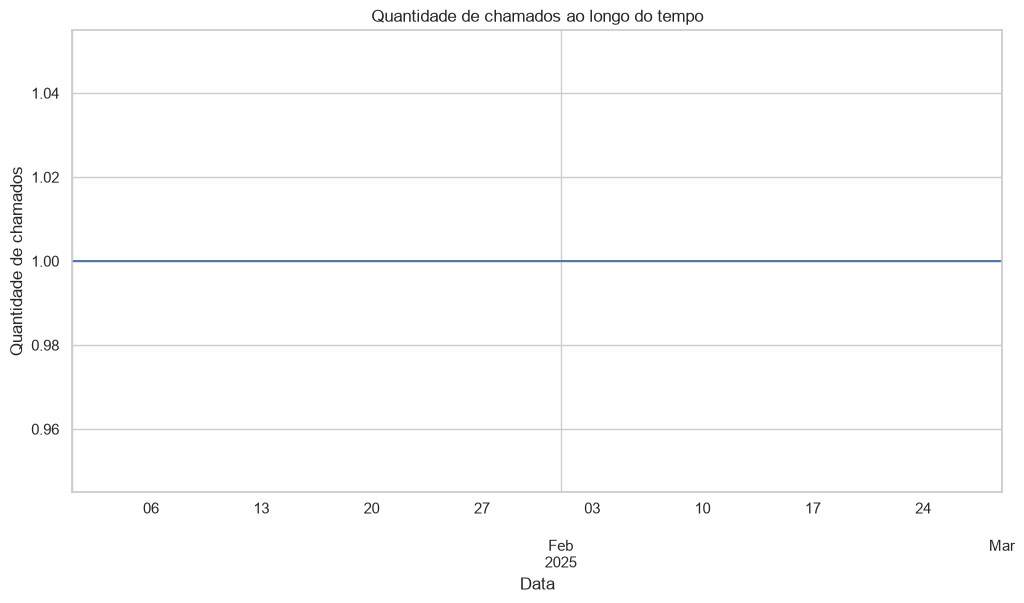

In [22]:
chamados_por_dia = (df.groupby("created_at").size())

plt.figure(figsize=(12, 6))

chamados_por_dia.plot()

plt.title("Quantidade de chamados ao longo do tempo")
plt.xlabel("Data")
plt.ylabel("Quantidade de chamados")

plt.show()

In [23]:
df["status"].value_counts()

status
Aberto          1689
Fechado         1657
Em andamento    1654
Name: count, dtype: int64

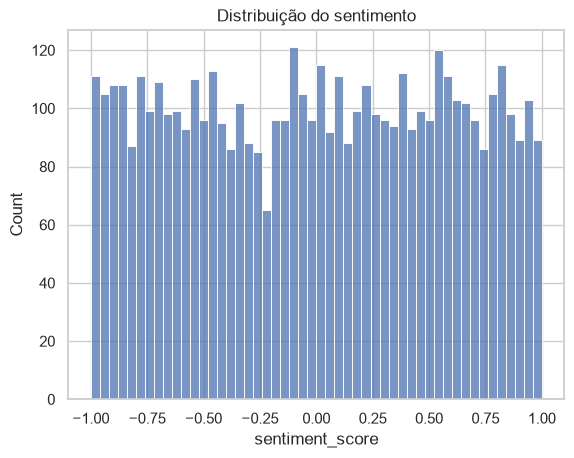

In [30]:
sns.histplot(
    data=df,
    x="sentiment_score",
    bins=50
)

plt.title("Distribuição do sentimento")

plt.show()

In [31]:
df.groupby("priority")["sentiment_score"].mean()

priority
Alta      -0.008653
Baixa     -0.014359
Crítica   -0.012071
Média      0.022493
Name: sentiment_score, dtype: float64

In [32]:
df.groupby("target_category")["sentiment_score"].mean()

target_category
Acesso        0.001501
Financeiro   -0.036249
Hardware     -0.011800
RH            0.004334
Rede         -0.002289
Software      0.021296
Name: sentiment_score, dtype: float64

In [37]:
df.groupby("title")["target_category"].nunique().sort_values(ascending=False)

title
O usuário não consegue abrir documento devido a apresenta er...    2
O usuário não consegue abrir documento devido a congela.           2
O usuário não consegue abrir documento devido a desliga.           2
O usuário não consegue abrir documento devido a emite beep.        2
O usuário não consegue abrir documento devido a fica lento.        2
                                                                  ..
A conexão de rede está desliga e ruído.                            1
A conexão de rede está desliga e tela piscando.                    1
A conexão de rede está desliga e tela preta.                       1
A conexão de rede está emite beep e cheiro de queimado.            1
A conexão de rede está apresenta erro e sem resposta.              1
Name: target_category, Length: 2519, dtype: int64

In [38]:
pd.crosstab(df["state_x"],
    df["target_category"])

target_category,Acesso,Financeiro,Hardware,RH,Rede,Software
state_x,,,,,,
BA,134,131,140,141,143,148
MG,148,133,141,128,134,150
PR,129,119,128,120,154,146
RJ,133,124,126,130,148,161
RS,138,128,161,149,145,141
SP,139,135,139,153,137,146
